<a href="https://colab.research.google.com/github/AkashssA/MACHINE_LEARNING_2/blob/main/ml2finds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("student.csv")

print(df)


    student_id  age  gender  studyhours  attendance  marks result
0            1   18    Male           4        92.0     85   Pass
1            2   19  Female           6        95.0     91   Pass
2            3   18    Male           2        62.0     45   Fail
3            4   20  Female           7        98.0     88   Pass
4            5   19    Male           3        85.0     52   Fail
5            6   21  Female           1        58.0     38   Fail
6            7   18    Male           5        90.0     76   Pass
7            8   20  Female           2        70.0     49   Fail
8            9   19    Male           8        96.0     94   Pass
9           10   21  Female           3        80.0     55   Pass
10          11   18  Female           6        91.0     82   Pass
11          12   20    Male           4        65.0     61   Fail
12          13   19  Female           5        88.0     73   Pass
13          14   21    Male           1        55.0     35   Fail
14        

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
print(df.head())
print(df.info())
print(df.isnull().sum())

   student_id  age  gender  studyhours  attendance  marks result
0           1   18    Male           4        92.0     85   Pass
1           2   19  Female           6        95.0     91   Pass
2           3   18    Male           2        62.0     45   Fail
3           4   20  Female           7        98.0     88   Pass
4           5   19    Male           3        85.0     52   Fail
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   student_id  30 non-null     int64  
 1   age         30 non-null     int64  
 2   gender      30 non-null     object 
 3   studyhours  30 non-null     int64  
 4   attendance  30 non-null     float64
 5   marks       30 non-null     int64  
 6   result      30 non-null     object 
dtypes: float64(1), int64(4), object(2)
memory usage: 1.8+ KB
None
student_id    0
age           0
gender        0
studyhours    0
attendan

In [ ]:

df.fillna(df.mean(numeric_only=True),inplace=True)


In [ ]:
print(df.isnull().sum())

student_id    0
age           0
gender        0
studyhours    0
attendance    0
marks         0
result        0
dtype: int64


In [ ]:
x=df[["age",'studyhours','attendance','marks']]

In [ ]:
y=df[['result']]

In [ ]:
##convert class label to numerical
encoder=LabelEncoder()
y=encoder.fit_transform(y)
print(y)

[1 1 0 1 0 0 1 0 1 1 1 0 1 0 1 0 1 0 0 1 0 1 0 0 1 0 0 1 1 0]


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
print("Trainning samples",len(x_train))
print("Testing samples",len(x_test))

Trainning samples 24
Testing samples 6


In [ ]:
model=DecisionTreeClassifier(random_state=42)
model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
print("Actual",y_test)
print("Predicted",y_pred)

Actual [1 0 1 0 1 0]
Predicted [0 0 0 0 1 0]


In [ ]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [ ]:
print("Accuracy",accuracy)
print("Precision",precision)
print("Recall",recall)
print("F1",f1)

Accuracy 0.6666666666666666
Precision 1.0
Recall 0.3333333333333333
F1 0.5


In [ ]:
cm=confusion_matrix(y_test,y_pred)
print("Confusion matrix")
print(cm)

Confusion matrix
[[3 0]
 [2 1]]


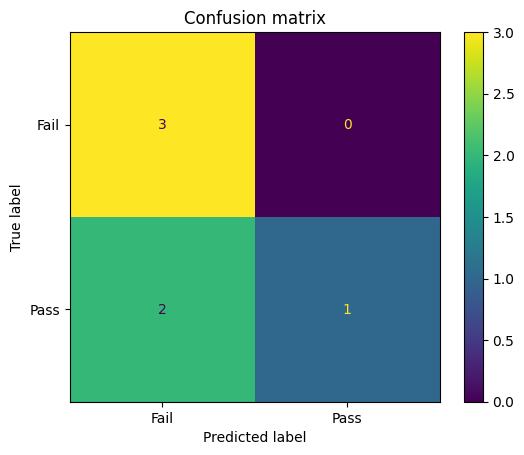

In [ ]:

disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)
disp.plot()
plt.title("Confusion matrix")
plt.show()